## 1. Import Libraries

In [1]:
# Install extra libraries used later in the notebook (SHAP explainability, ngrok for Flask)
!pip install -q shap
!pip -q install pyngrok

In [2]:
# Core libraries
import os
import time
import subprocess
import joblib
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Boosting / explainability
import xgboost
from xgboost import XGBClassifier
import shap

# Colab / Flask deployment helpers
from google.colab import files
from google.colab.output import eval_js

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


## 2. Load Dataset

In [3]:
df_train=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  object 
 10  galaxy_population  247435 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 20.8+ MB


In [6]:
df_train.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [7]:
df_test.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000
mean,701064.000000,181.360629,21.853898,22.442070,21.009837,19.965651,19.381860,19.043151,0.724780
std,71428.476266,96.213374,18.931367,2.019044,1.798633,1.650949,1.581880,1.587103,0.810582
min,577347.000000,0.010959,-17.959259,13.902664,13.374549,10.390731,10.034180,10.632025,-0.009968
25%,639205.500000,132.023953,2.527822,20.978208,19.866076,18.831805,18.314240,17.976477,0.183117
50%,701064.000000,188.559428,21.452023,22.569616,21.469175,20.431512,19.632235,19.196316,0.498598
75%,762922.500000,231.690068,37.061924,23.869689,22.294539,21.165467,20.618391,20.167750,0.882659
max,824781.000000,359.999724,79.170436,27.835633,27.173411,25.291984,24.567823,25.700336,7.007179


## 3. Exploratory Data Analysis

### Class Distribution

In [8]:
df_train["class"].value_counts(normalize=True)*100

,proportion
class,
GALAXY,65.381824
QSO,20.289878
STAR,14.328298


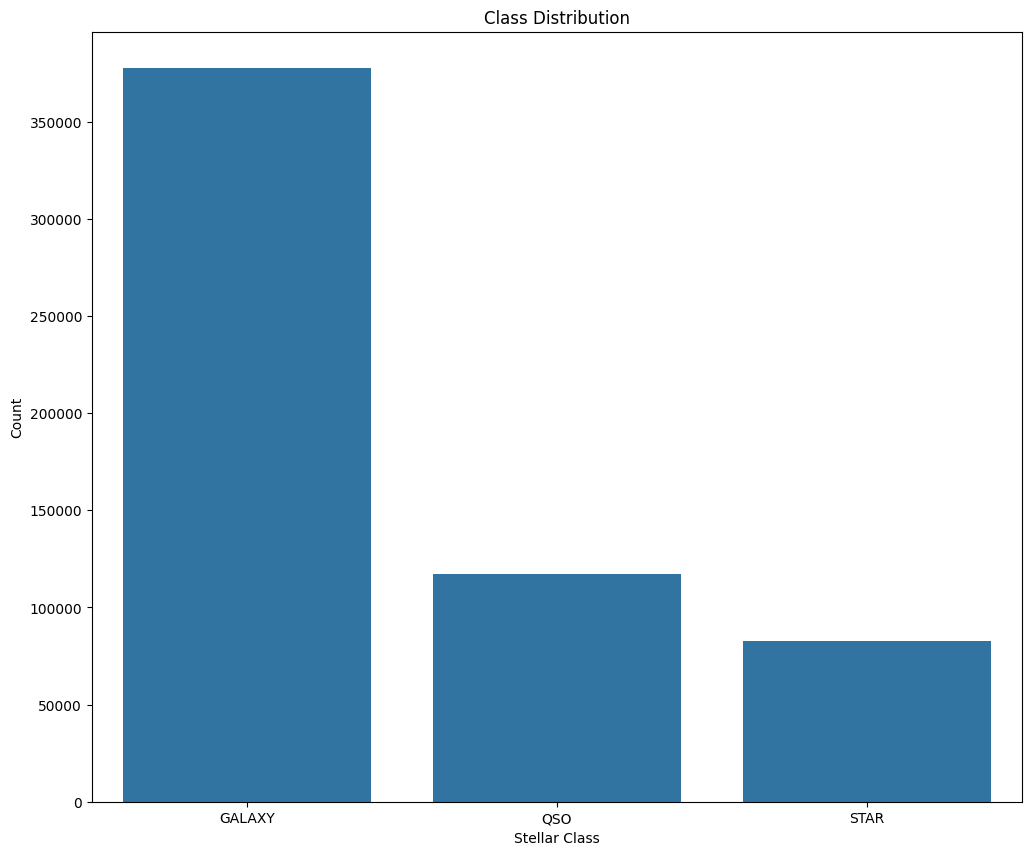

In [9]:
plt.figure(figsize=(12,10))
sns.countplot(
    data=df_train,
    x="class",
    order=df_train["class"].value_counts().index
)

plt.title("Class Distribution")
plt.xlabel("Stellar Class")
plt.ylabel("Count")
plt.show()

In [10]:
print(df_train["class"].value_counts())
df_train[df_train["class"] == "GA"]

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class


In [11]:
# replace GA with Galaxy
df_train['class']=df_train['class'].replace('GA','GALAXY')
print(df_train["class"].value_counts())

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


In [12]:
df_train.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class'],
      dtype='object')

### Missing Values

In [13]:
df_train.isnull().sum()

,0
id,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
spectral_type,0


In [14]:
df_test.isnull().sum()

,0
id,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
spectral_type,0


### Duplicates

In [15]:
print("Duplicate rows in training data:", df_train.duplicated().sum())
print("Duplicate rows in test data:", df_test.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


In [16]:
print("Duplicate rows in training data excluding id:",
      df_train.drop(columns=['id']).duplicated().sum())

print("Duplicate rows in test data excluding id:",
      df_test.drop(columns=['id']).duplicated().sum())

Duplicate rows in training data excluding id: 0
Duplicate rows in test data excluding id: 0


### Numerical Feature Analysis

In [17]:
numerical_features=['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


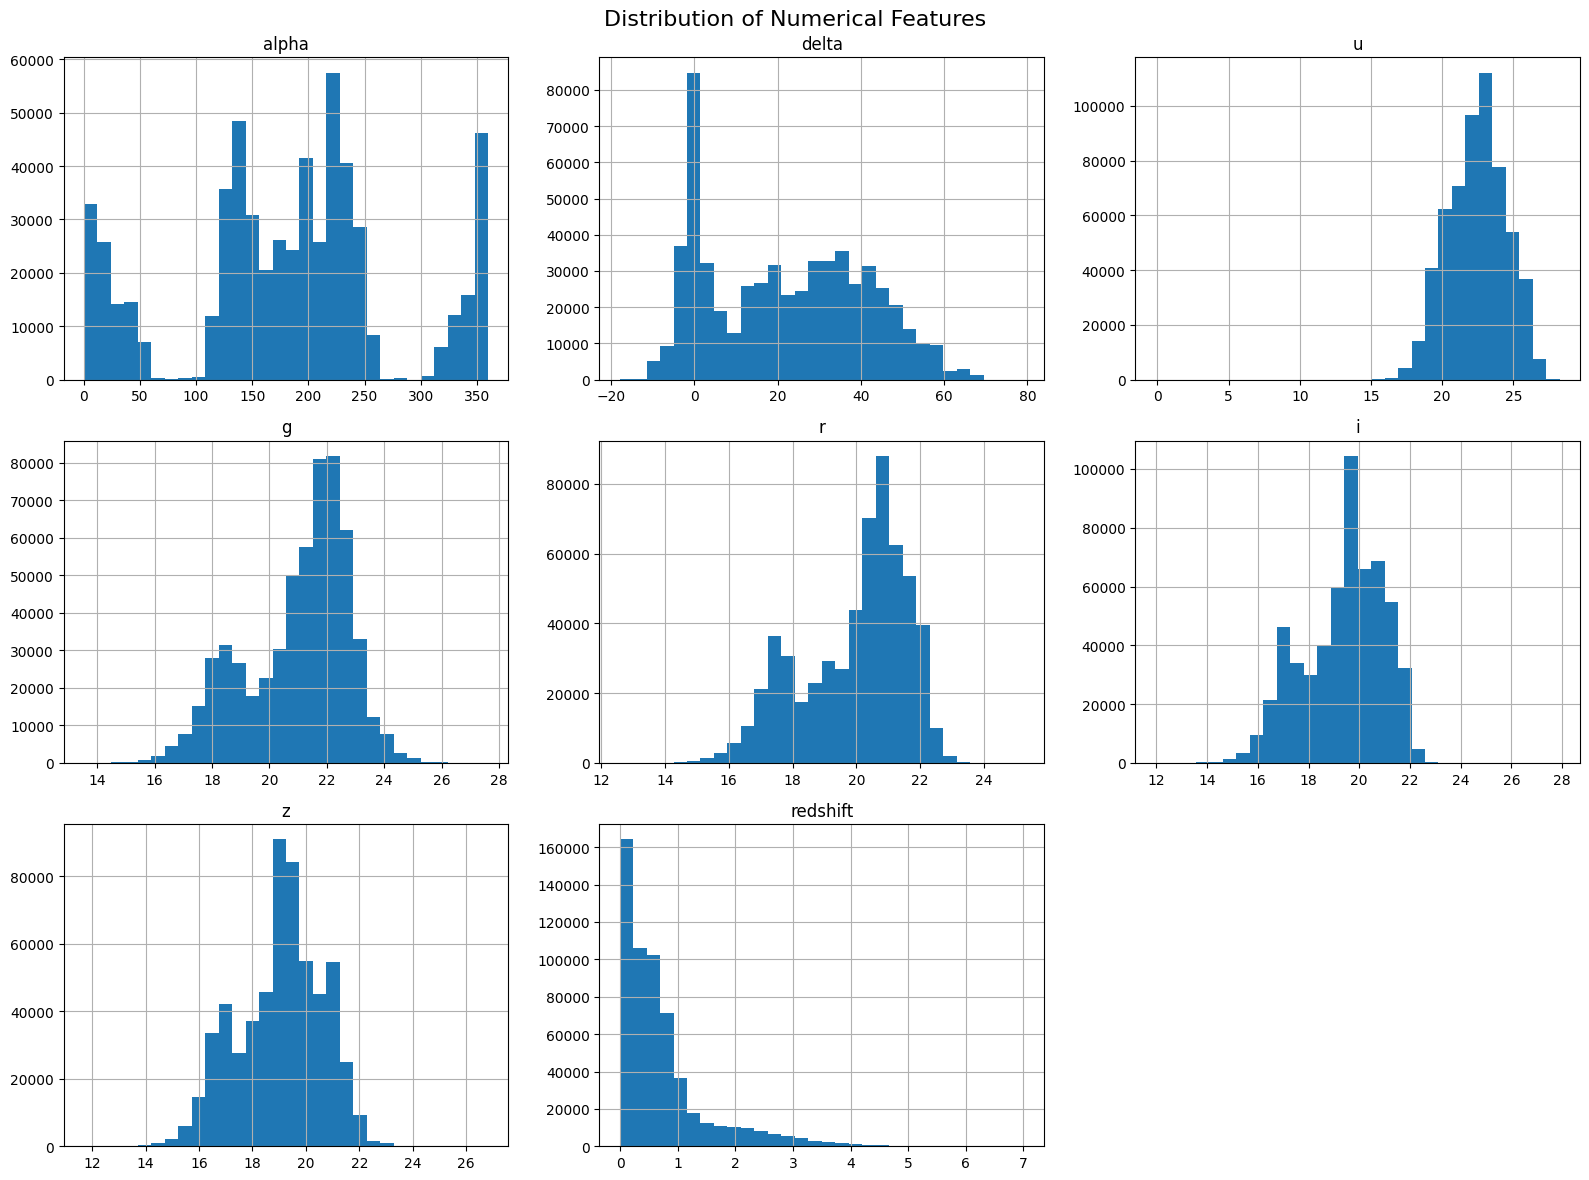

In [18]:
df_train[numerical_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

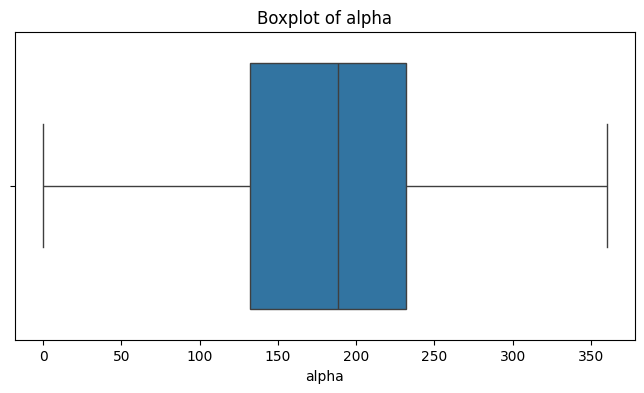

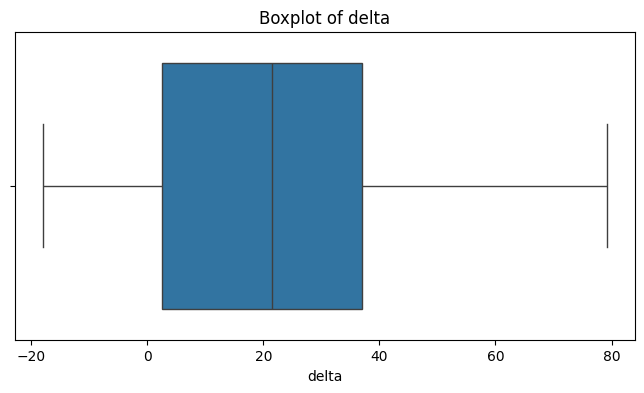

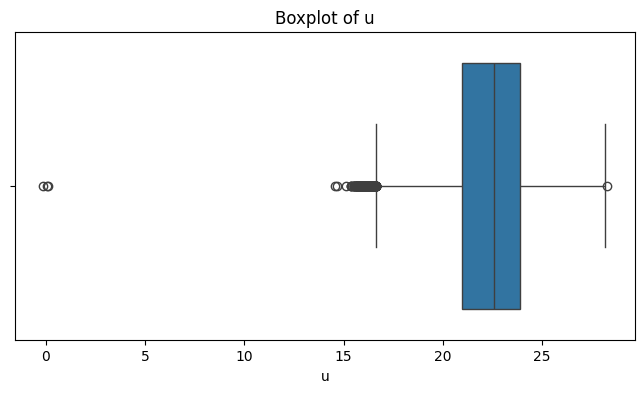

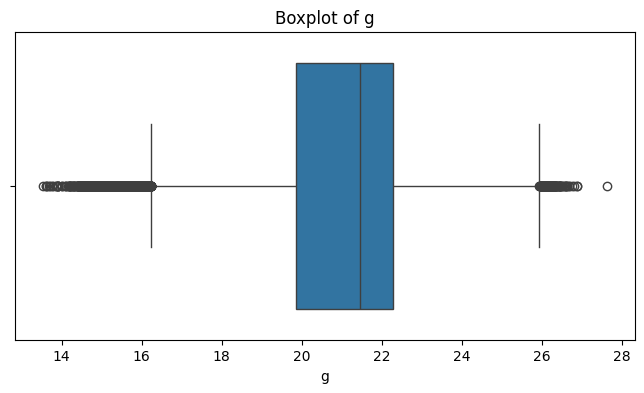

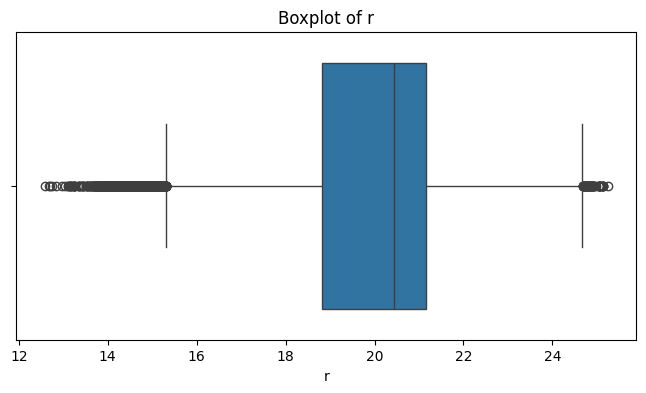

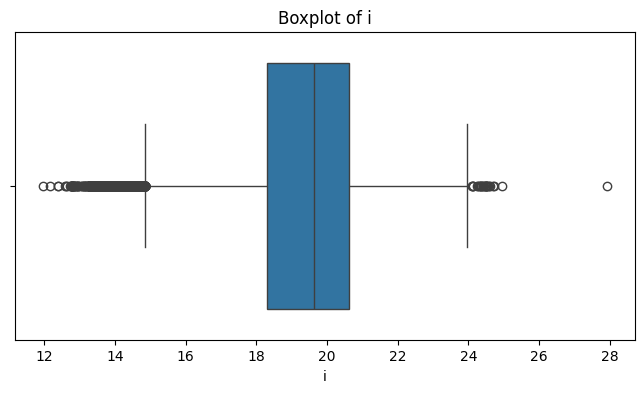

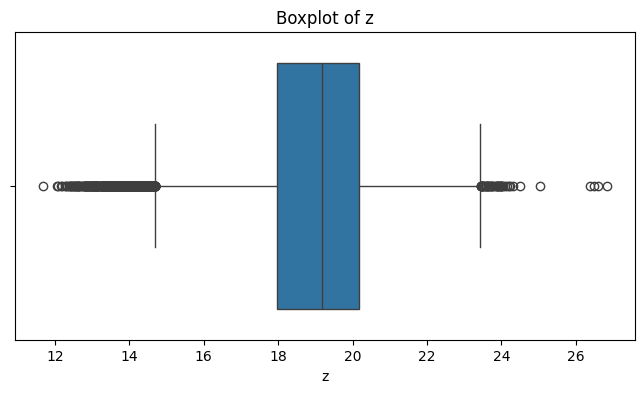

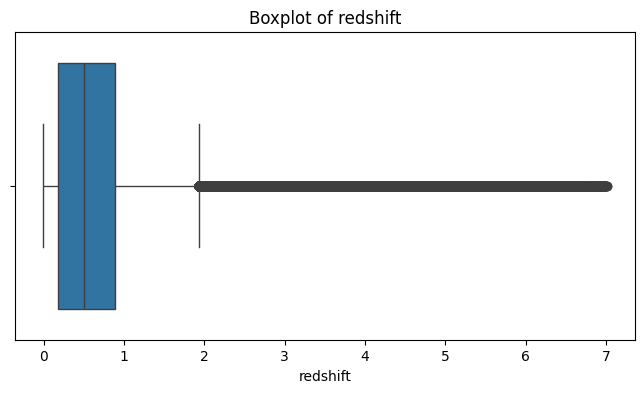

In [19]:
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ).sum()


for col in numerical_features:
    print(f"{col}: {count_outliers(df_train, col)}")

alpha: 0
delta: 0
u: 315
g: 2806
r: 1677
i: 1277
z: 1476
redshift: 52590


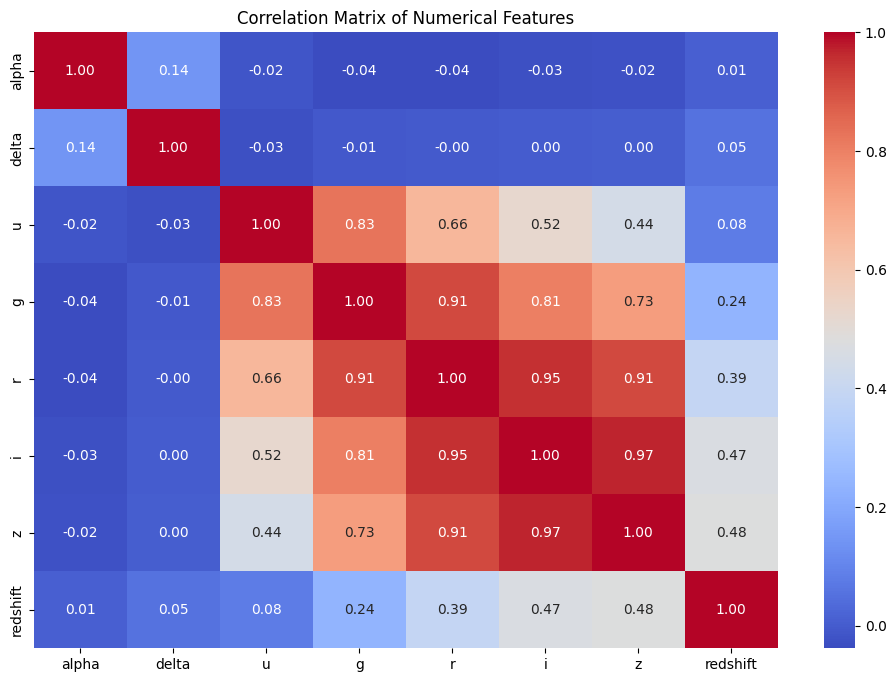

In [21]:
correlation_matrix = df_train[numerical_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [22]:
import numpy as np
corr_matrix = df_train[numerical_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

for column in upper_triangle.columns:
    for index in upper_triangle.index:
        if upper_triangle.loc[index, column] > 0.90:
            print(
                f"{index} and {column}: "
                f"{upper_triangle.loc[index, column]:.4f}"
            )

g and r: 0.9121
r and i: 0.9535
r and z: 0.9133
i and z: 0.9687


### Class-wise Numerical Analysis

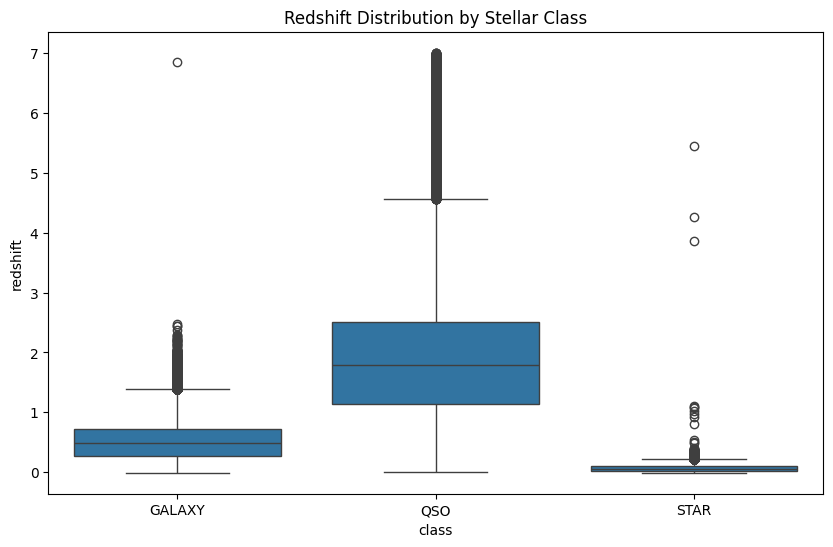

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_train,
    x='class',
    y='redshift'
)

plt.title("Redshift Distribution by Stellar Class")
plt.show()

In [24]:
plot_sample = df_train.sample(
    n=10000,
    random_state=42
)

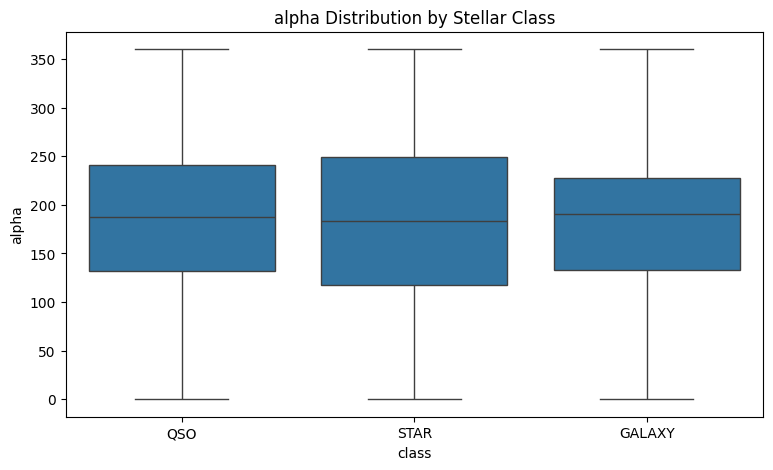

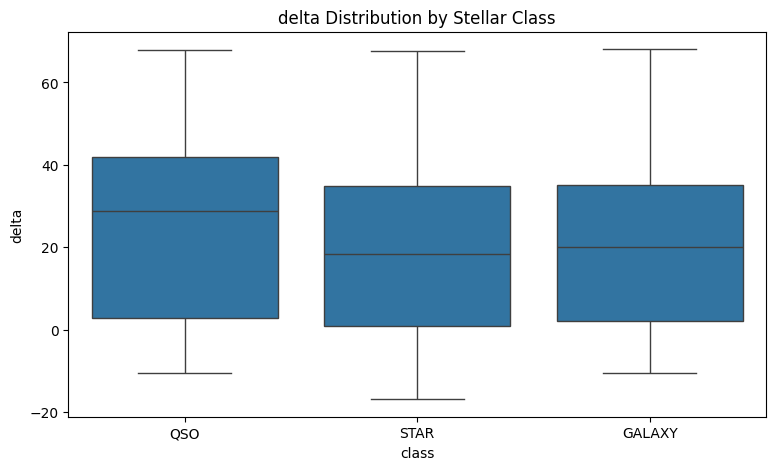

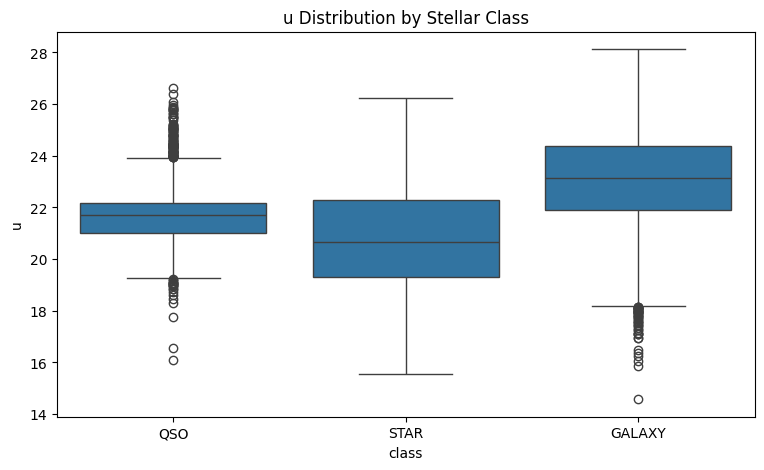

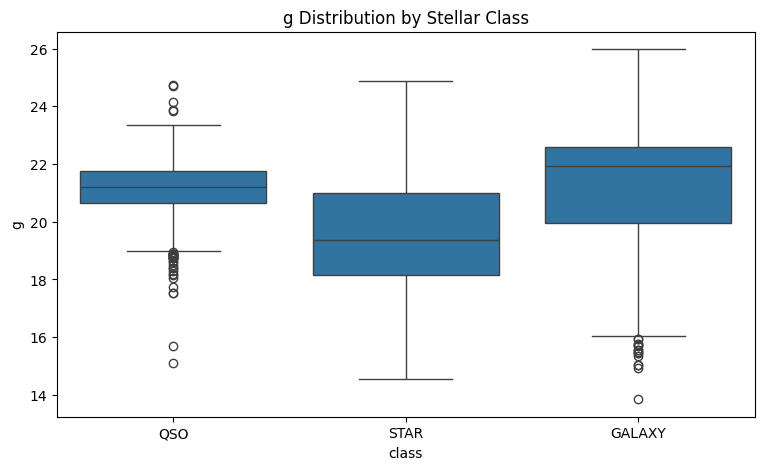

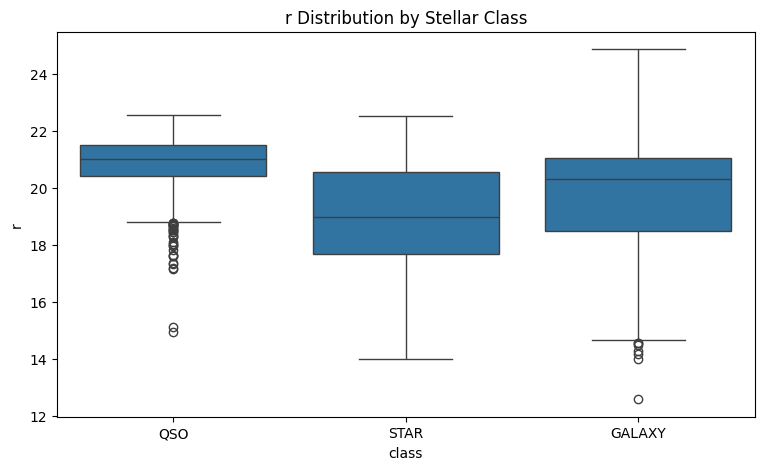

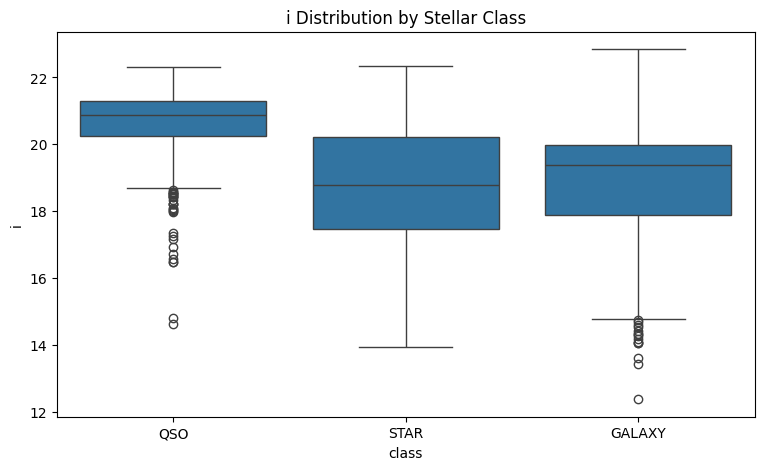

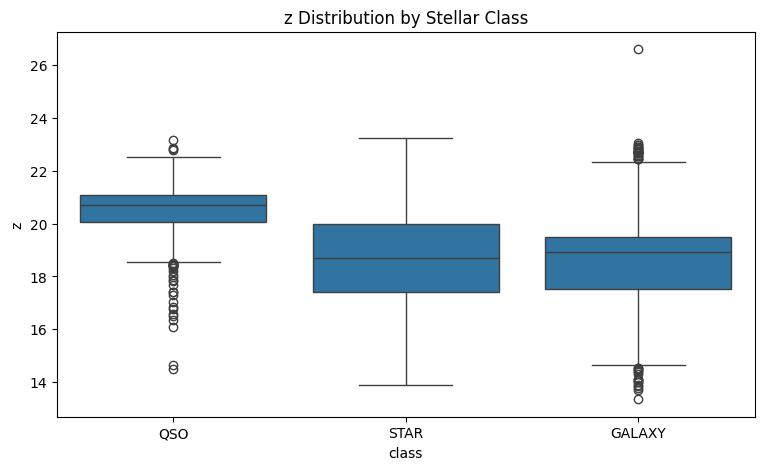

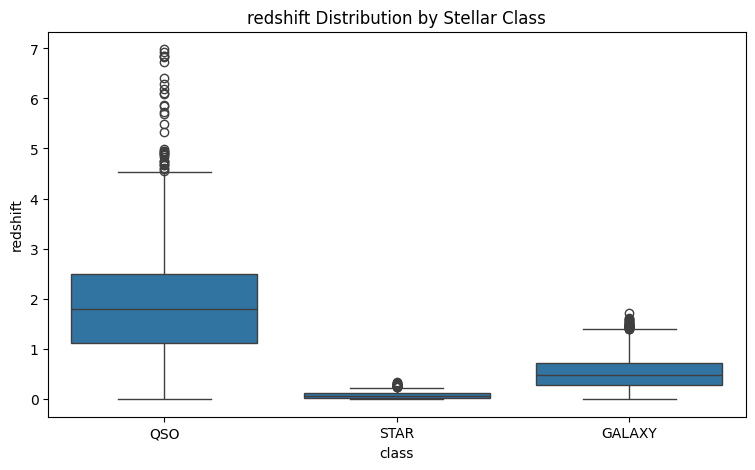

In [25]:
for col in numerical_features:
    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=plot_sample,
        x='class',
        y=col
    )

    plt.title(f"{col} Distribution by Stellar Class")
    plt.show()

### Categorical Feature Analysis

In [26]:
print("Spectral Type Distribution:")
print(df_train['spectral_type'].value_counts())

print("\nGalaxy Population Distribution:")
print(df_train['galaxy_population'].value_counts())

Spectral Type Distribution:
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

Galaxy Population Distribution:
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64


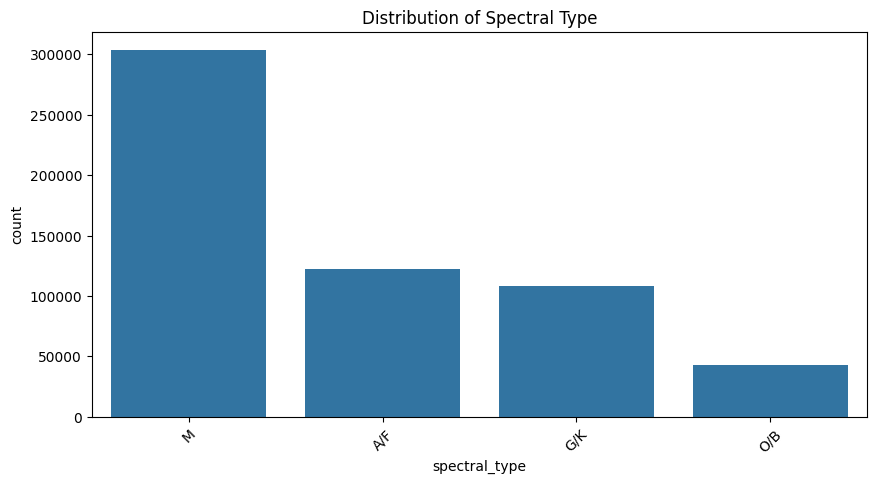

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_train,
    x='spectral_type',
    order=df_train['spectral_type'].value_counts().index
)

plt.title("Distribution of Spectral Type")
plt.xticks(rotation=45)
plt.show()

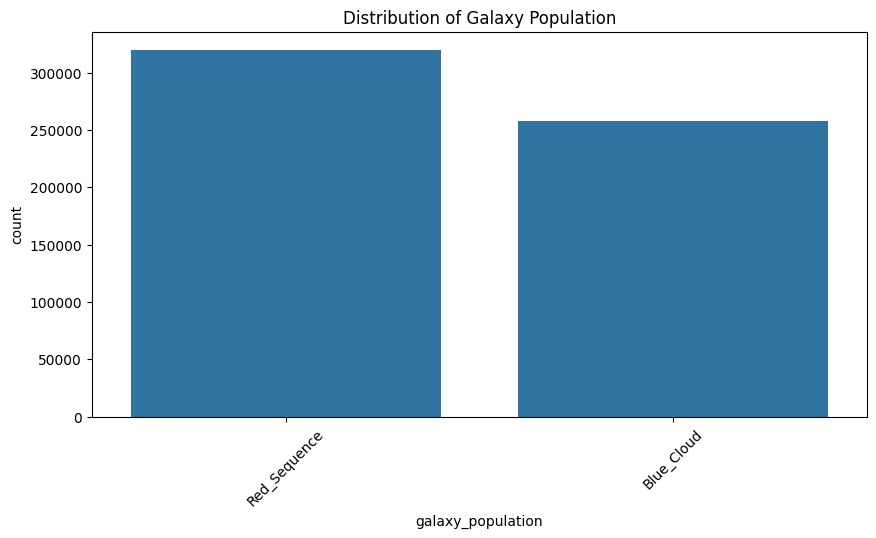

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_train,
    x='galaxy_population',
    order=df_train['galaxy_population'].value_counts().index
)

plt.title("Distribution of Galaxy Population")
plt.xticks(rotation=45)
plt.show()

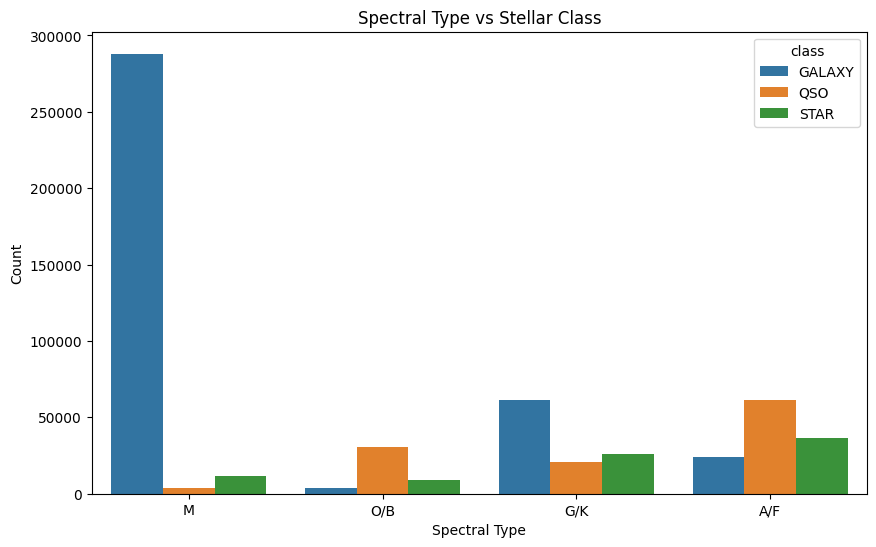

In [29]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_train,
    x='spectral_type',
    hue='class'
)

plt.title("Spectral Type vs Stellar Class")
plt.xlabel("Spectral Type")
plt.ylabel("Count")
plt.show()

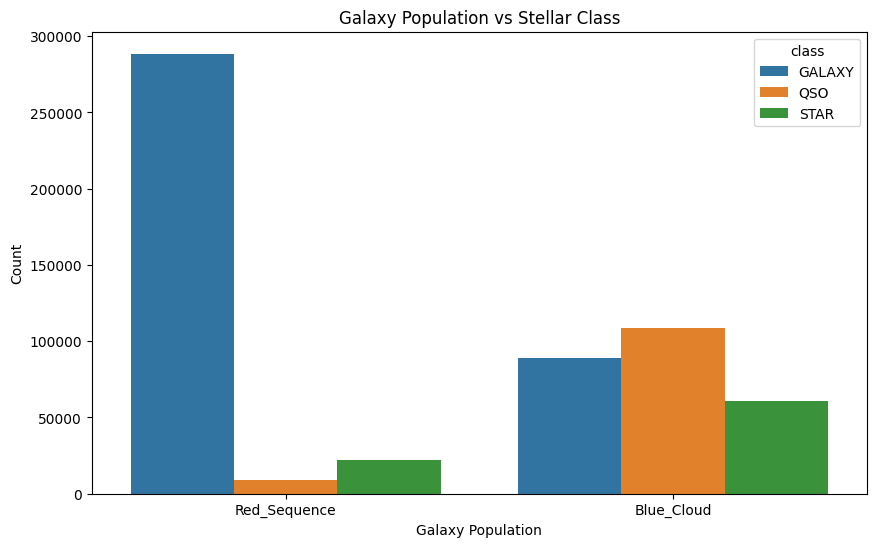

In [30]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_train,
    x='galaxy_population',
    hue='class'
)

plt.title("Galaxy Population vs Stellar Class")
plt.xlabel("Galaxy Population")
plt.ylabel("Count")
plt.show()

## 4. Feature Engineering

*(Placed before Preprocessing since the engineered columns must already exist on `train`/`test` before X and y are created.)*

In [31]:
# Create copies
train = df_train.copy()
test = df_test.copy()

In [32]:
# Feature Engineering: Color Indices

train["u_g"] = train["u"] - train["g"]
train["g_r"] = train["g"] - train["r"]
train["r_i"] = train["r"] - train["i"]
train["i_z"] = train["i"] - train["z"]

test["u_g"] = test["u"] - test["g"]
test["g_r"] = test["g"] - test["r"]
test["r_i"] = test["r"] - test["i"]
test["i_z"] = test["i"] - test["z"]

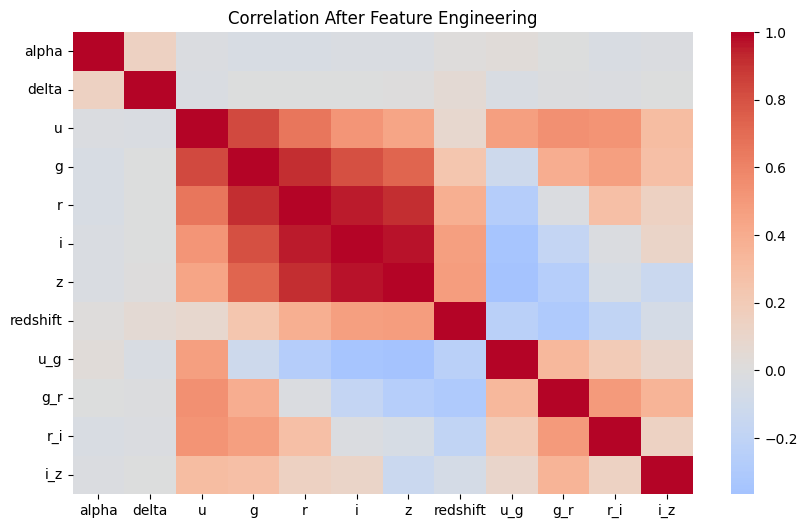

In [33]:
new_features = ["u_g", "g_r", "r_i", "i_z"]

train[new_features].describe()
plt.figure(figsize=(10, 6))

sns.heatmap(
    train[numerical_features + new_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation After Feature Engineering")
plt.show()

## 5. Preprocessing

In [34]:
X = train.drop(columns=["class", "id"])
y = train["class"]

X_test = test.drop(columns=["id"])

In [35]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['GALAXY' 'QSO' 'STAR']


In [36]:
categorical_features = [
    "spectral_type",
    "galaxy_population"
]

numerical_features_final = [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift",
    "u_g",
    "g_r",
    "r_i",
    "i_z"
]

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [38]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [39]:
print(X_train.shape)
print(X_valid.shape)
print(label_encoder.classes_)

(461877, 14)
(115470, 14)
['GALAXY' 'QSO' 'STAR']


## 6. Stratified K-Fold Cross-Validation

In [40]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Stratified K-Fold Cross-Validation")
print("Number of folds:", skf.n_splits)

Stratified K-Fold Cross-Validation
Number of folds: 3


In [41]:
# Check class distribution in each Stratified K-Fold

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded), 1):
    print(f"\nFold {fold}")
    print("Training samples:", len(train_idx))
    print("Validation samples:", len(valid_idx))

    print("\nTraining class distribution:")
    print(pd.Series(y_encoded[train_idx]).value_counts(normalize=True).sort_index())

    print("\nValidation class distribution:")
    print(pd.Series(y_encoded[valid_idx]).value_counts(normalize=True).sort_index())


Fold 1
Training samples: 384898
Validation samples: 192449

Training class distribution:
0    0.653817
1    0.202898
2    0.143285
Name: proportion, dtype: float64

Validation class distribution:
0    0.653820
1    0.202901
2    0.143280
Name: proportion, dtype: float64

Fold 2
Training samples: 384898
Validation samples: 192449

Training class distribution:
0    0.653817
1    0.202901
2    0.143282
Name: proportion, dtype: float64

Validation class distribution:
0    0.653820
1    0.202895
2    0.143285
Name: proportion, dtype: float64

Fold 3
Training samples: 384898
Validation samples: 192449

Training class distribution:
0    0.653820
1    0.202898
2    0.143282
Name: proportion, dtype: float64

Validation class distribution:
0    0.653815
1    0.202901
2    0.143285
Name: proportion, dtype: float64


In [42]:
# Actual Stratified K-Fold Cross-Validation using XGBoost
# (Same XGBoost configuration used later for the main XGBoost model)

cv_accuracy = []
cv_balanced_accuracy = []
cv_f1 = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded), 1):

    X_fold_train, X_fold_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_fold_train, y_fold_valid = y_encoded[train_idx], y_encoded[valid_idx]

    fold_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=30,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                eval_metric="mlogloss"
            ))
        ]
    )

    fold_pipeline.fit(X_fold_train, y_fold_train)

    fold_pred = fold_pipeline.predict(X_fold_valid)

    fold_acc = accuracy_score(y_fold_valid, fold_pred)
    fold_bal_acc = balanced_accuracy_score(y_fold_valid, fold_pred)
    fold_f1 = f1_score(y_fold_valid, fold_pred, average="weighted")

    cv_accuracy.append(fold_acc)
    cv_balanced_accuracy.append(fold_bal_acc)
    cv_f1.append(fold_f1)

    print(f"Fold {fold} -> Accuracy: {fold_acc:.4f}, "
          f"Balanced Accuracy: {fold_bal_acc:.4f}, F1: {fold_f1:.4f}")

print("\nMean CV Accuracy:", sum(cv_accuracy) / len(cv_accuracy))
print("Mean CV Balanced Accuracy:", sum(cv_balanced_accuracy) / len(cv_balanced_accuracy))
print("Mean CV F1 Score:", sum(cv_f1) / len(cv_f1))

Fold 1 -> Accuracy: 0.9583, Balanced Accuracy: 0.9399, F1: 0.9581
Fold 2 -> Accuracy: 0.9576, Balanced Accuracy: 0.9392, F1: 0.9575
Fold 3 -> Accuracy: 0.9581, Balanced Accuracy: 0.9403, F1: 0.9580

Mean CV Accuracy: 0.9580235109907905
Mean CV Balanced Accuracy: 0.9398226209293968
Mean CV F1 Score: 0.9578937950722958


## 7. Decision Tree

In [43]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [44]:
decision_tree_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['spectral_type',
                                                   'galaxy_population'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [45]:
y_pred_dt = decision_tree_pipeline.predict(X_valid)

In [46]:
print("Decision Tree Performance\n")

print("Accuracy:",
      accuracy_score(y_valid, y_pred_dt))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_valid, y_pred_dt))

print("Precision:",
      precision_score(
          y_valid,
          y_pred_dt,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_valid,
          y_pred_dt,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_valid,
          y_pred_dt,
          average="weighted"
      ))

Decision Tree Performance

Accuracy: 0.937568199532346
Balanced Accuracy: 0.9145465089003334
Precision: 0.9374600098586284
Recall: 0.937568199532346
F1 Score: 0.9375114958921285


In [47]:
print(
    classification_report(
        y_valid,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.95      0.96      0.96     75496
         QSO       0.94      0.94      0.94     23429
        STAR       0.85      0.85      0.85     16545

    accuracy                           0.94    115470
   macro avg       0.92      0.91      0.92    115470
weighted avg       0.94      0.94      0.94    115470



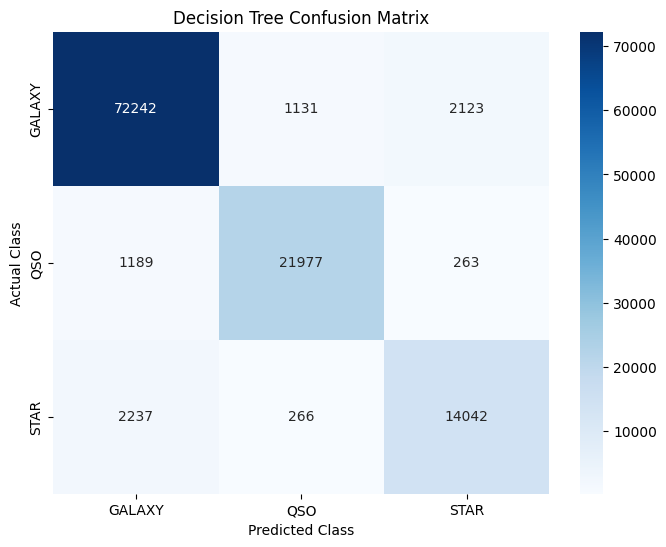

In [48]:
cm_dt = confusion_matrix(y_valid, y_pred_dt)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree Confusion Matrix")

plt.show()

### Decision Tree Hyperparameter Experiments

In [49]:
# Create a smaller stratified dataset for quick hyperparameter experiments

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    random_state=42,
    stratify=y_train
)

print("Tuning dataset shape:", X_tune.shape)

Tuning dataset shape: (100000, 14)


In [50]:
# Decision Tree Hyperparameter Experiment


dt_results = []

dt_configs = [
    {"criterion": "gini", "max_depth": 5, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "gini", "max_depth": 15, "min_samples_split": 5, "min_samples_leaf": 2}
]

for config in dt_configs:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(
                **config,
                random_state=42
            ))
        ]
    )

    model.fit(X_tune, y_tune)

    pred = model.predict(X_valid)

    dt_results.append({
        "Configuration": str(config),
        "Accuracy": accuracy_score(y_valid, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_valid, pred),
        "F1 Score": f1_score(y_valid, pred, average="weighted")
    })

dt_results_df = pd.DataFrame(dt_results)

display(dt_results_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
))

,Configuration,Accuracy,Balanced Accuracy,F1 Score
1,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.944349,0.921276,0.944138
2,"{'criterion': 'gini', 'max_depth': 15, 'min_sa...",0.939794,0.910037,0.939371
0,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.919754,0.873421,0.918629


### Decision Tree Visualization

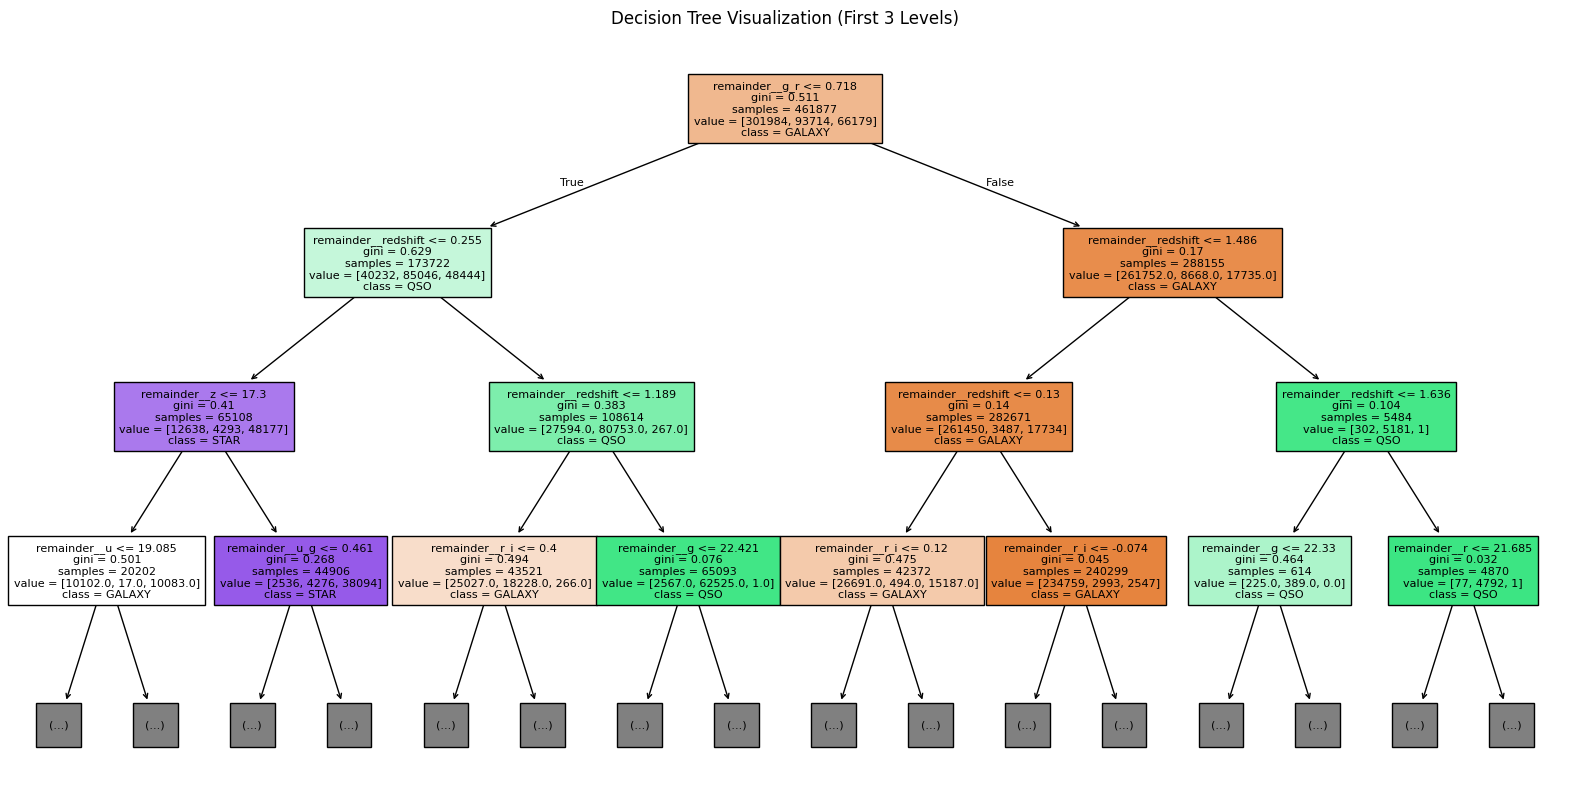

In [51]:
# Decision Tree Visualization


dt_model = decision_tree_pipeline.named_steps["model"]
dt_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

feature_names_dt = dt_preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=label_encoder.classes_,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

## 8. Random Forest

In [52]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=25,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [53]:
random_forest_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['spectral_type',
                                                   'galaxy_population'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=25, n_jobs=-1,
                                        random_state=42))])

In [54]:
y_pred_rf = random_forest_pipeline.predict(X_valid)

In [55]:
print("Random Forest Performance\n")

print("Accuracy:",
      accuracy_score(y_valid, y_pred_rf))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_valid, y_pred_rf))

print("Precision:",
      precision_score(
          y_valid,
          y_pred_rf,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_valid,
          y_pred_rf,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_valid,
          y_pred_rf,
          average="weighted"
      ))

Random Forest Performance

Accuracy: 0.9573309084610722
Balanced Accuracy: 0.9378957961301041
Precision: 0.9570801229055468
Recall: 0.9573309084610722
F1 Score: 0.9571678972693985


In [56]:
print(
    classification_report(
        y_valid,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.91      0.88      0.89     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.94    115470
weighted avg       0.96      0.96      0.96    115470



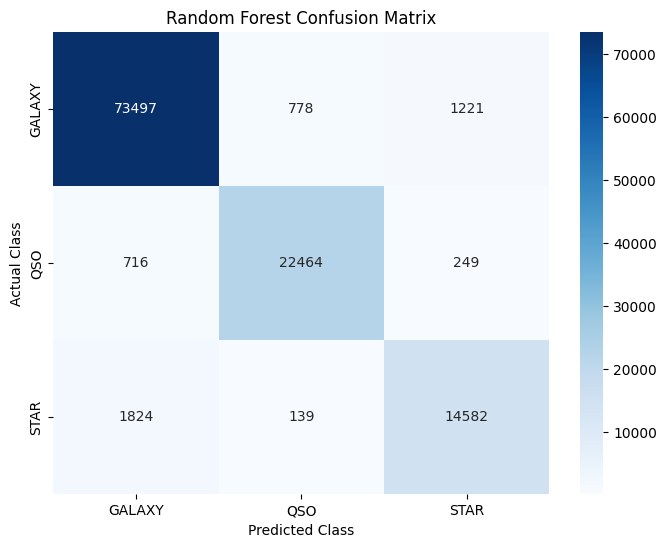

In [57]:
cm_rf = confusion_matrix(y_valid, y_pred_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest Confusion Matrix")

plt.show()

## 9. Boosting Models

### Random Forest Hyperparameter Experiments

In [58]:
# Random Forest Hyperparameter Experiment

rf_results = []

rf_configs = [
    {
        "n_estimators": 10,
        "max_depth": 10,
        "max_features": "sqrt",
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 25,
        "max_depth": 15,
        "max_features": "sqrt",
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 40,
        "max_depth": 15,
        "max_features": "sqrt",
        "min_samples_leaf": 2
    }
]

for config in rf_configs:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                **config,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]
    )

    model.fit(X_tune, y_tune)

    pred = model.predict(X_valid)

    rf_results.append({
        "Configuration": str(config),
        "Accuracy": accuracy_score(y_valid, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_valid, pred),
        "F1 Score": f1_score(y_valid, pred, average="weighted")
    })

rf_results_df = pd.DataFrame(rf_results)

display(
    rf_results_df.sort_values(
        by="Balanced Accuracy",
        ascending=False
    )
)

,Configuration,Accuracy,Balanced Accuracy,F1 Score
2,"{'n_estimators': 40, 'max_depth': 15, 'max_fea...",0.951702,0.944696,0.952053
0,"{'n_estimators': 10, 'max_depth': 10, 'max_fea...",0.939499,0.944479,0.940624
1,"{'n_estimators': 25, 'max_depth': 15, 'max_fea...",0.951892,0.941824,0.952128


### AdaBoost

In [59]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', AdaBoostClassifier(
            n_estimators=20,
            learning_rate=1.0,
            random_state=42
        ))
    ]
)

adaboost_pipeline.fit(X_train, y_train)

y_pred_ada = adaboost_pipeline.predict(X_valid)

ada_accuracy = accuracy_score(y_valid, y_pred_ada)
ada_balanced_accuracy = balanced_accuracy_score(y_valid, y_pred_ada)
ada_precision = precision_score(y_valid, y_pred_ada, average='weighted')
ada_recall = recall_score(y_valid, y_pred_ada, average='weighted')
ada_f1 = f1_score(y_valid, y_pred_ada, average='weighted')

print("AdaBoost Results")
print("Accuracy:", ada_accuracy)
print("Balanced Accuracy:", ada_balanced_accuracy)
print("Precision:", ada_precision)
print("Recall:", ada_recall)
print("F1 Score:", ada_f1)

AdaBoost Results
Accuracy: 0.8835888109465662
Balanced Accuracy: 0.8668918777900695
Precision: 0.8901589332356131
Recall: 0.8835888109465662
F1 Score: 0.8858465330631093


### Gradient Boosting

In [60]:
# Use a smaller stratified subset for Gradient Boosting
X_gb, _, y_gb, _ = train_test_split(
    X_train,
    y_train,
    train_size=50000,
    random_state=42,
    stratify=y_train
)

gradient_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=15,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_pipeline.fit(X_gb, y_gb)

y_pred_gb = gradient_pipeline.predict(X_valid)

gb_accuracy = accuracy_score(y_valid, y_pred_gb)
gb_balanced_accuracy = balanced_accuracy_score(y_valid, y_pred_gb)
gb_precision = precision_score(y_valid, y_pred_gb, average='weighted')
gb_recall = recall_score(y_valid, y_pred_gb, average='weighted')
gb_f1 = f1_score(y_valid, y_pred_gb, average='weighted')

print("Gradient Boosting Results")
print("Accuracy:", gb_accuracy)
print("Balanced Accuracy:", gb_balanced_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.9315579804278168
Balanced Accuracy: 0.8806422564470536
Precision: 0.9308355195880237
Recall: 0.9315579804278168
F1 Score: 0.9299955813360299

Confusion Matrix:
[[73768   764   964]
 [ 1490 21287   652]
 [ 3851   182 12512]]


### XGBoost

In [61]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=30,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                eval_metric="mlogloss"
            )
        )
    ]
)

In [62]:
xgb_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['spectral_type',
                                                   'galaxy_population'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               en...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=30, n_jobs=-1, num_class=3, ...))])

In [63]:
y_pred_xgb = xgb_pipeline.predict(X_valid)

In [64]:
print("XGBoost Performance\n")

print("Accuracy:",
      accuracy_score(y_valid, y_pred_xgb))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_valid, y_pred_xgb))

print("Precision:",
      precision_score(
          y_valid,
          y_pred_xgb,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_valid,
          y_pred_xgb,
          average="weighted"
      ))

print("F1 Score:",
      f1_score(
          y_valid,
          y_pred_xgb,
          average="weighted"
      ))

XGBoost Performance

Accuracy: 0.9582142547847926
Balanced Accuracy: 0.9390945489662809
Precision: 0.9579627125450609
Recall: 0.9582142547847926
F1 Score: 0.9580481938259314


In [65]:
print(
    classification_report(
        y_valid,
        y_pred_xgb,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.91      0.88      0.90     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.94    115470
weighted avg       0.96      0.96      0.96    115470



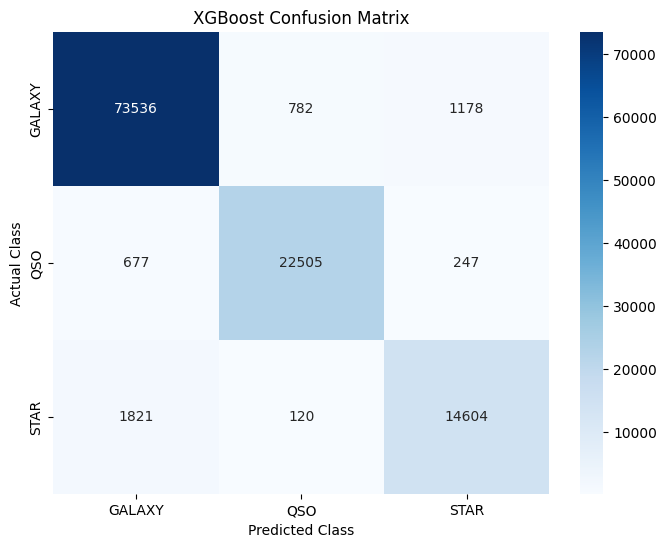

In [66]:
cm_xgb = confusion_matrix(y_valid, y_pred_xgb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("XGBoost Confusion Matrix")

plt.show()

### XGBoost Hyperparameter Experiments

In [67]:
# XGBoost Hyperparameter Experiment


xgb_results = []

xgb_configs = [
    {
        "n_estimators": 20,
        "max_depth": 6,
        "learning_rate": 0.1
    },
    {
        "n_estimators": 30,
        "max_depth": 8,
        "learning_rate": 0.1
    },
    {
        "n_estimators": 40,
        "max_depth": 8,
        "learning_rate": 0.05
    }
]

for config in xgb_configs:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                eval_metric="mlogloss",
                **config
            ))
        ]
    )

    model.fit(X_tune, y_tune)

    pred = model.predict(X_valid)

    xgb_results.append({
        "Configuration": str(config),
        "Accuracy": accuracy_score(y_valid, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_valid, pred),
        "F1 Score": f1_score(y_valid, pred, average="weighted")
    })

xgb_results_df = pd.DataFrame(xgb_results)

display(xgb_results_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
))

,Configuration,Accuracy,Balanced Accuracy,F1 Score
1,"{'n_estimators': 30, 'max_depth': 8, 'learning...",0.956560,0.935369,0.956351
2,"{'n_estimators': 40, 'max_depth': 8, 'learning...",0.953806,0.926743,0.953355
0,"{'n_estimators': 20, 'max_depth': 6, 'learning...",0.949892,0.919846,0.949311


## 10. Model Comparison

In [68]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_xgb),
        ada_accuracy,
        gb_accuracy
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_valid, y_pred_dt),
        balanced_accuracy_score(y_valid, y_pred_rf),
        balanced_accuracy_score(y_valid, y_pred_xgb),
        ada_balanced_accuracy,
        gb_balanced_accuracy
    ],
    'Precision': [
        precision_score(y_valid, y_pred_dt, average='weighted'),
        precision_score(y_valid, y_pred_rf, average='weighted'),
        precision_score(y_valid, y_pred_xgb, average='weighted'),
        ada_precision,
        gb_precision
    ],
    'Recall': [
        recall_score(y_valid, y_pred_dt, average='weighted'),
        recall_score(y_valid, y_pred_rf, average='weighted'),
        recall_score(y_valid, y_pred_xgb, average='weighted'),
        ada_recall,
        gb_recall
    ],
    'F1 Score': [
        f1_score(y_valid, y_pred_dt, average='weighted'),
        f1_score(y_valid, y_pred_rf, average='weighted'),
        f1_score(y_valid, y_pred_xgb, average='weighted'),
        ada_f1,
        gb_f1
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.958214,0.939095,0.957963,0.958214,0.958048
1,Random Forest,0.957331,0.937896,0.957080,0.957331,0.957168
0,Decision Tree,0.937568,0.914547,0.937460,0.937568,0.937511
4,Gradient Boosting,0.931558,0.880642,0.930836,0.931558,0.929996
3,AdaBoost,0.883589,0.866892,0.890159,0.883589,0.885847


## 11. Feature Importance

In [69]:
# XGBoost Feature Importance

xgb_model = xgb_pipeline.named_steps['model']

feature_names = xgb_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

Top 15 Important Features:


,Feature,Importance
2,cat__spectral_type_M,0.648951
13,remainder__redshift,0.093648
15,remainder__g_r,0.069451
4,cat__galaxy_population_Blue_Cloud,0.034285
5,cat__galaxy_population_Red_Sequence,0.025247
12,remainder__z,0.023388
9,remainder__g,0.018032
14,remainder__u_g,0.016015
8,remainder__u,0.013199
3,cat__spectral_type_O/B,0.013166


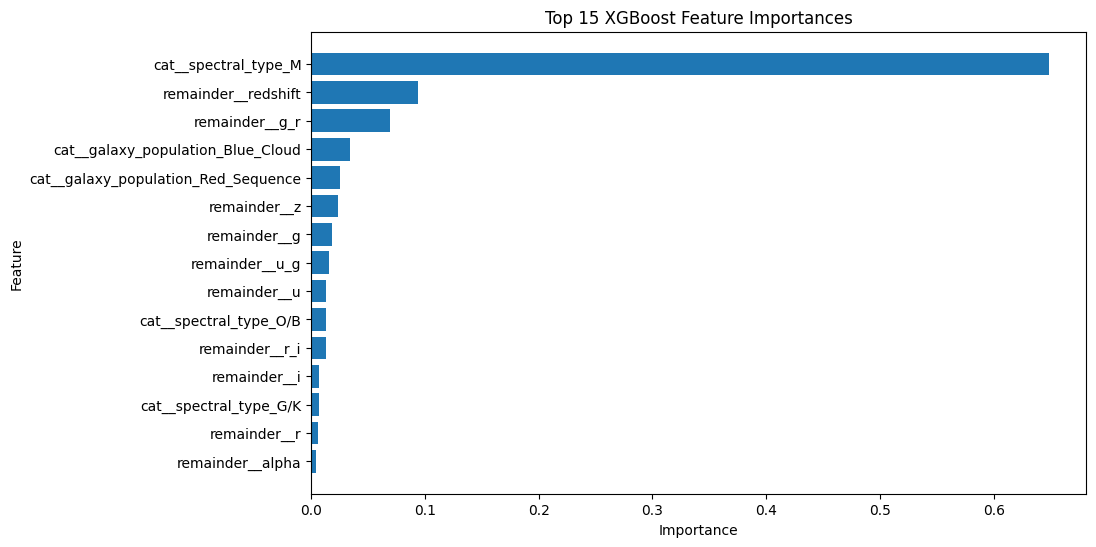

In [70]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values(
    by='Importance'
)

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

## 12. SHAP Analysis

In [71]:
# Take a small sample for SHAP analysis

X_shap = X_valid.sample(
    n=2000,
    random_state=42
)

# Get fitted XGBoost components
xgb_preprocessor = xgb_pipeline.named_steps['preprocessor']
xgb_model = xgb_pipeline.named_steps['model']

# Transform the sample
X_shap_transformed = xgb_preprocessor.transform(X_shap)

# Get transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

print("SHAP sample shape:", X_shap.shape)
print("Transformed shape:", X_shap_transformed.shape)

SHAP sample shape: (2000, 14)
Transformed shape: (2000, 18)


In [72]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_shap_transformed
)

print("SHAP analysis completed.")

SHAP analysis completed.


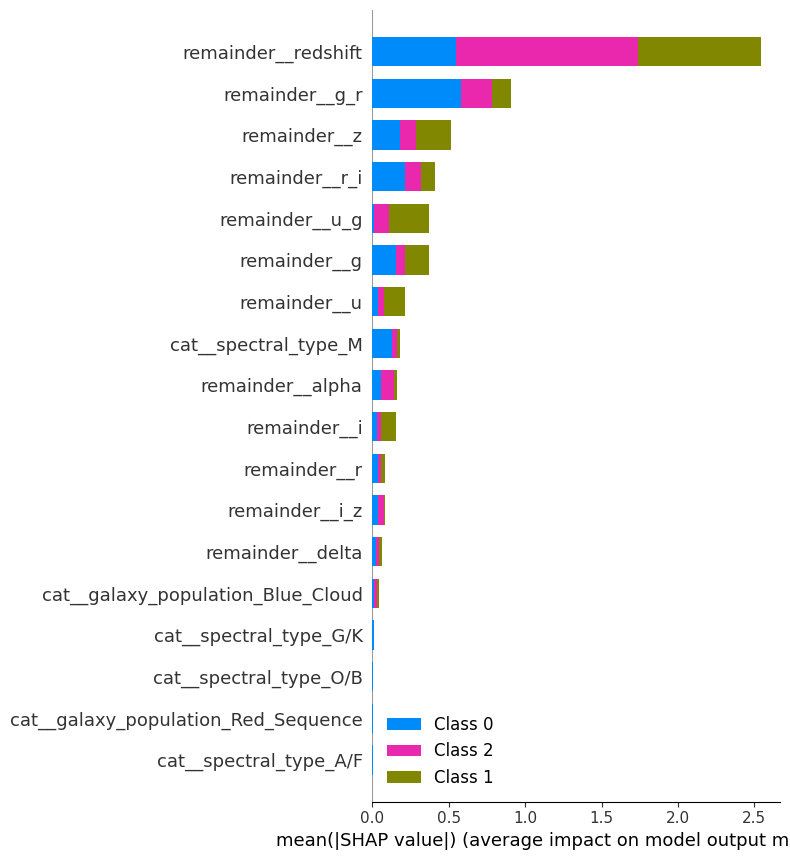

In [73]:
# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

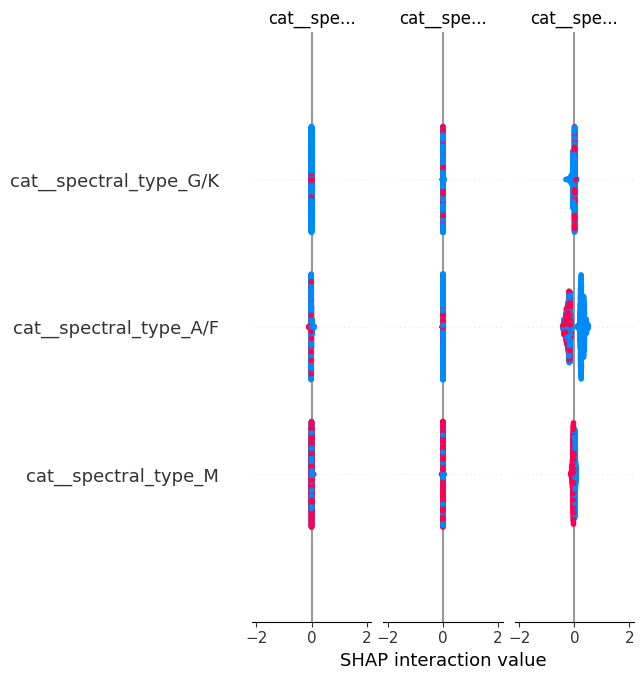

In [74]:
# SHAP Summary / Beeswarm Plot

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names
)

In [75]:
top_2_features = feature_importance.head(2)['Feature'].tolist()

print("Top 2 important features:")
print(top_2_features)

Top 2 important features:
['cat__spectral_type_M', 'remainder__redshift']


In [76]:
print("SHAP values shape:", np.array(shap_values).shape)
print("Transformed X shape:", X_shap_transformed.shape)
print("Number of features:", len(feature_names))

SHAP values shape: (2000, 18, 3)
Transformed X shape: (2000, 18)
Number of features: 18


In [77]:
# Select SHAP values for GALAXY (class 0)
shap_values_galaxy = np.array(shap_values)[:, :, 0]

print("GALAXY SHAP shape:", shap_values_galaxy.shape)

GALAXY SHAP shape: (2000, 18)


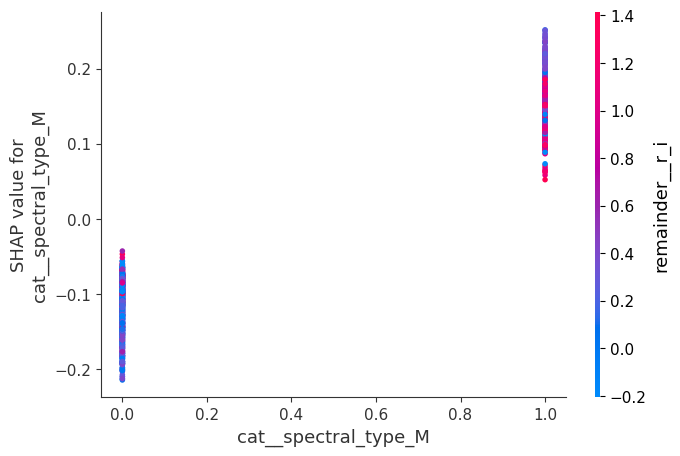

In [78]:
shap.dependence_plot(
    top_2_features[0],
    shap_values_galaxy,
    X_shap_transformed,
    feature_names=feature_names
)

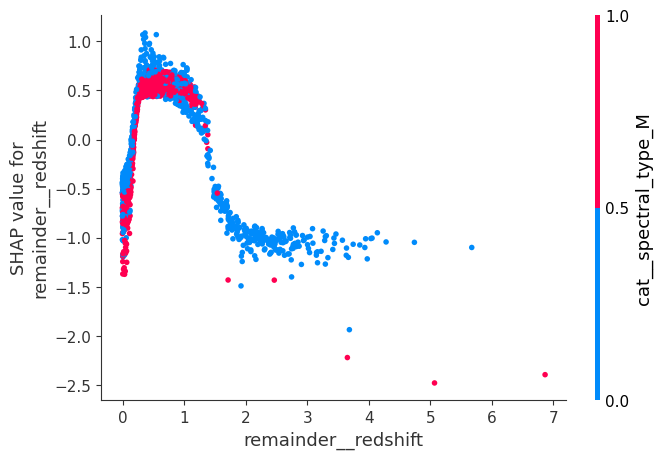

In [79]:
shap.dependence_plot(
    top_2_features[1],
    shap_values_galaxy,
    X_shap_transformed,
    feature_names=feature_names
)


--- Prediction 1 ---


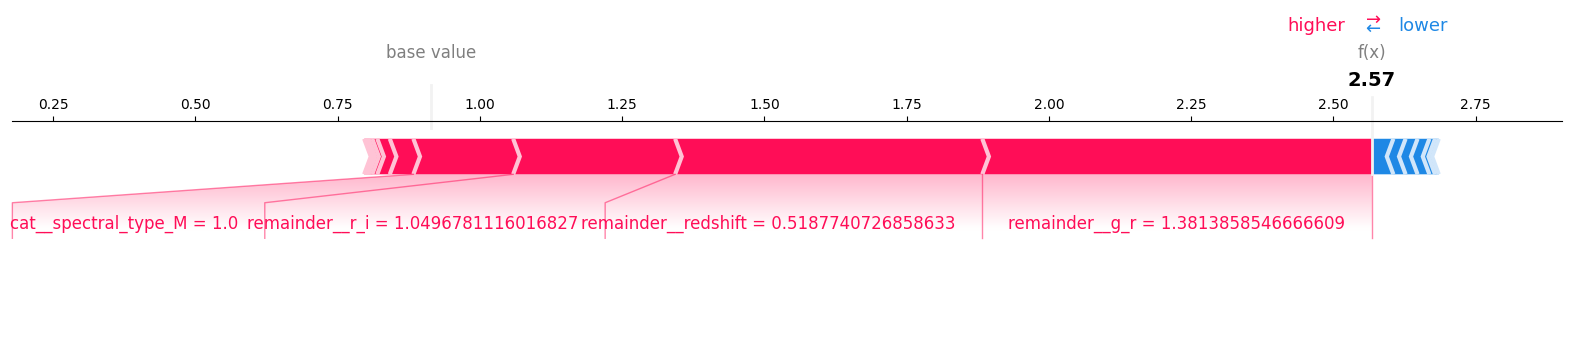


--- Prediction 2 ---


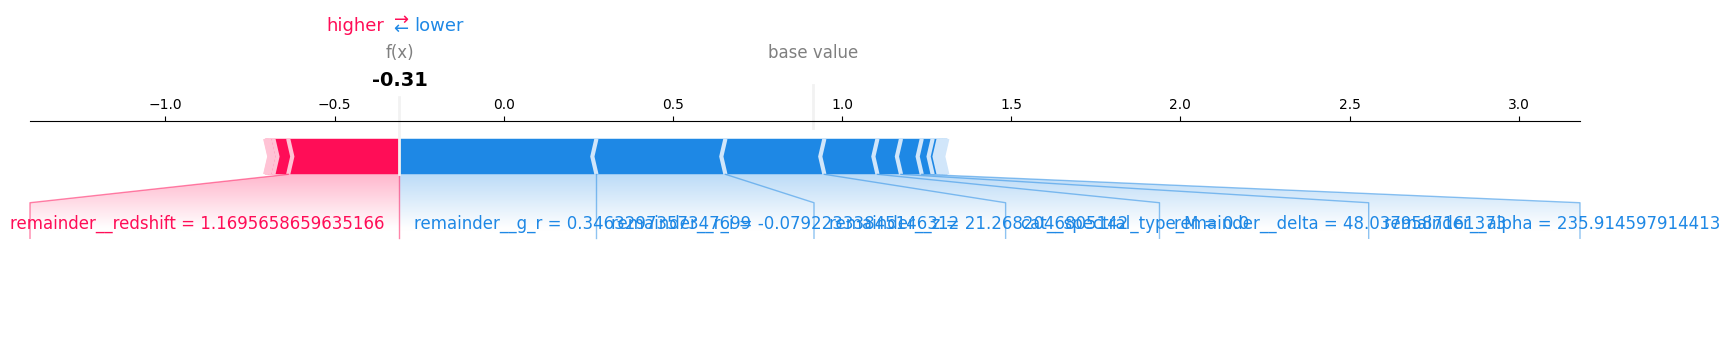

In [80]:
# Select two observations from the SHAP sample
for idx in [0, 1]:
    print(f"\n--- Prediction {idx + 1} ---")

    shap.force_plot(
        explainer.expected_value[0],
        shap_values_galaxy[idx],
        X_shap_transformed[idx],
        feature_names=feature_names,
        matplotlib=True
    )

## 13. Ensemble Learning

In [81]:
from sklearn.ensemble import VotingClassifier

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('dt', decision_tree_pipeline),
        ('rf', random_forest_pipeline),
        ('xgb', xgb_pipeline)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_valid)

print("Ensemble Accuracy:", accuracy_score(y_valid, y_pred_ensemble))
print("Ensemble Balanced Accuracy:", balanced_accuracy_score(y_valid, y_pred_ensemble))
print("Ensemble Precision:", precision_score(y_valid, y_pred_ensemble, average='weighted'))
print("Ensemble Recall:", recall_score(y_valid, y_pred_ensemble, average='weighted'))
print("Ensemble F1 Score:", f1_score(y_valid, y_pred_ensemble, average='weighted'))

Ensemble Accuracy: 0.953555035940071
Ensemble Balanced Accuracy: 0.9339934830053339
Ensemble Precision: 0.9533616380715385
Ensemble Recall: 0.953555035940071
Ensemble F1 Score: 0.9534387841842442


## 14. Final Model Selection

In [82]:
# Final comparison of all models

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Gradient Boosting",
        "AdaBoost",
        "Soft Voting Ensemble"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_xgb),
        accuracy_score(y_valid, y_pred_gb),
        accuracy_score(y_valid, y_pred_ada),
        accuracy_score(y_valid, y_pred_ensemble)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_valid, y_pred_dt),
        balanced_accuracy_score(y_valid, y_pred_rf),
        balanced_accuracy_score(y_valid, y_pred_xgb),
        balanced_accuracy_score(y_valid, y_pred_gb),
        balanced_accuracy_score(y_valid, y_pred_ada),
        balanced_accuracy_score(y_valid, y_pred_ensemble)
    ],
    "Precision": [
        precision_score(y_valid, y_pred_dt, average='weighted'),
        precision_score(y_valid, y_pred_rf, average='weighted'),
        precision_score(y_valid, y_pred_xgb, average='weighted'),
        precision_score(y_valid, y_pred_gb, average='weighted'),
        precision_score(y_valid, y_pred_ada, average='weighted'),
        precision_score(y_valid, y_pred_ensemble, average='weighted')
    ],
    "Recall": [
        recall_score(y_valid, y_pred_dt, average='weighted'),
        recall_score(y_valid, y_pred_rf, average='weighted'),
        recall_score(y_valid, y_pred_xgb, average='weighted'),
        recall_score(y_valid, y_pred_gb, average='weighted'),
        recall_score(y_valid, y_pred_ada, average='weighted'),
        recall_score(y_valid, y_pred_ensemble, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_valid, y_pred_dt, average='weighted'),
        f1_score(y_valid, y_pred_rf, average='weighted'),
        f1_score(y_valid, y_pred_xgb, average='weighted'),
        f1_score(y_valid, y_pred_gb, average='weighted'),
        f1_score(y_valid, y_pred_ada, average='weighted'),
        f1_score(y_valid, y_pred_ensemble, average='weighted')
    ]
})

final_results = final_results.sort_values(
    by="Balanced Accuracy",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.958214,0.939095,0.957963,0.958214,0.958048
1,Random Forest,0.957331,0.937896,0.957080,0.957331,0.957168
2,Soft Voting Ensemble,0.953555,0.933993,0.953362,0.953555,0.953439
3,Decision Tree,0.937568,0.914547,0.937460,0.937568,0.937511
4,Gradient Boosting,0.931558,0.880642,0.930836,0.931558,0.929996
5,AdaBoost,0.883589,0.866892,0.890159,0.883589,0.885847


In [83]:
# Select the best model based on Balanced Accuracy

best_model_name = final_results.iloc[0]["Model"]

print("Best Model:", best_model_name)
print("Best Balanced Accuracy:",
      final_results.iloc[0]["Balanced Accuracy"])

Best Model: XGBoost
Best Balanced Accuracy: 0.9390945489662809


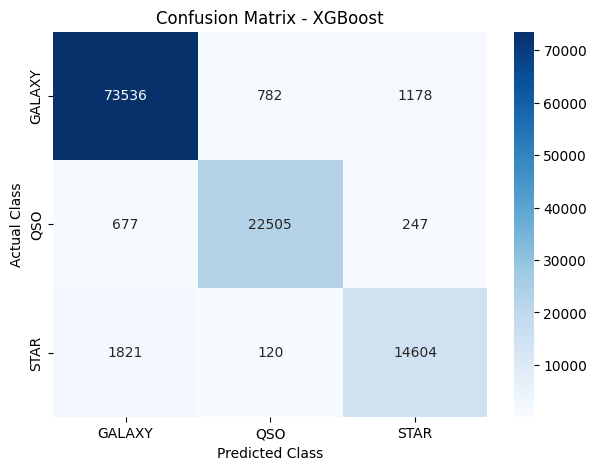

In [84]:
# Get predictions of the best model

predictions = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ada,
    "Soft Voting Ensemble": y_pred_ensemble
}

best_predictions = predictions[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_valid, best_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [85]:
# Final Classification Report

print(f"Classification Report - {best_model_name}\n")

print(
    classification_report(
        y_valid,
        best_predictions,
        target_names=label_encoder.classes_
    )
)

Classification Report - XGBoost

              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.91      0.88      0.90     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.94    115470
weighted avg       0.96      0.96      0.96    115470



In [86]:
# Final evaluation metrics

final_accuracy = accuracy_score(y_valid, best_predictions)
final_balanced_accuracy = balanced_accuracy_score(y_valid, best_predictions)
final_precision = precision_score(y_valid, best_predictions, average='weighted')
final_recall = recall_score(y_valid, best_predictions, average='weighted')
final_f1 = f1_score(y_valid, best_predictions, average='weighted')

print("Final Model:", best_model_name)
print(f"Accuracy:           {final_accuracy:.6f}")
print(f"Balanced Accuracy:  {final_balanced_accuracy:.6f}")
print(f"Precision:          {final_precision:.6f}")
print(f"Recall:             {final_recall:.6f}")
print(f"F1 Score:           {final_f1:.6f}")

Final Model: XGBoost
Accuracy:           0.958214
Balanced Accuracy:  0.939095
Precision:          0.957963
Recall:             0.958214
F1 Score:           0.958048


## 15. Final Cross-Validation Results

*(Recap of the Stratified K-Fold results computed in Section 6 - not re-run here.)*

In [87]:
# Final Cross-Validation Results

print("\n========== Cross-Validation Results ==========")

print("Fold Accuracy:", cv_accuracy)
print("Mean Accuracy:", sum(cv_accuracy) / len(cv_accuracy))

print("\nFold Balanced Accuracy:", cv_balanced_accuracy)
print(
    "Mean Balanced Accuracy:",
    sum(cv_balanced_accuracy) / len(cv_balanced_accuracy)
)

print("\nFold F1 Score:", cv_f1)
print("Mean F1 Score:", sum(cv_f1) / len(cv_f1))


========== Cross-Validation Results ==========
Fold Accuracy: [0.9582902483255304, 0.9576355294129874, 0.9581447552338541]
Mean Accuracy: 0.9580235109907905

Fold Balanced Accuracy: [np.float64(0.9399115289303667), np.float64(0.9392269273741439), np.float64(0.9403294064836801)]
Mean Balanced Accuracy: 0.9398226209293968

Fold F1 Score: [0.9581492364901243, 0.9574989145118376, 0.9580332342149251]
Mean F1 Score: 0.9578937950722958


## 16. Final Model Training

In [88]:
# Train the selected best model on the complete training dataset

final_model = predictions = None

if best_model_name == "Decision Tree":
    final_model = decision_tree_pipeline
elif best_model_name == "Random Forest":
    final_model = random_forest_pipeline
elif best_model_name == "XGBoost":
    final_model = xgb_pipeline
elif best_model_name == "Gradient Boosting":
    final_model = gradient_pipeline
elif best_model_name == "AdaBoost":
    final_model = adaboost_pipeline
elif best_model_name == "Soft Voting Ensemble":
    final_model = ensemble

final_model.fit(X, y_encoded)

print("Final model trained:", best_model_name)

Final model trained: XGBoost


## 17. Kaggle Submission

In [89]:
# Predict test set

test_predictions_encoded = final_model.predict(X_test)

# Convert encoded labels back to original class names
test_predictions = label_encoder.inverse_transform(test_predictions_encoded)

print("Test predictions generated.")
print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])

Test predictions generated.
Number of predictions: 247435
First 10 predictions: ['GALAXY' 'GALAXY' 'GALAXY' 'STAR' 'GALAXY' 'GALAXY' 'GALAXY' 'STAR'
 'GALAXY' 'GALAXY']


In [90]:
# Create Kaggle submission file

submission = pd.DataFrame({
    "id": df_test["id"],
    "class": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")
print("Shape:", submission.shape)
print("\nFirst 10 rows:")
print(submission.head(10))

Submission file created successfully!
Shape: (247435, 2)

First 10 rows:
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY


In [91]:
# Verify submission format

print("Columns:", submission.columns.tolist())
print("Number of rows:", len(submission))
print("Missing values:")
print(submission.isnull().sum())

print("\nClass distribution:")
print(submission["class"].value_counts())

Columns: ['id', 'class']
Number of rows: 247435
Missing values:
id       0
class    0
dtype: int64

Class distribution:
class
GALAXY    162805
QSO        50122
STAR       34508
Name: count, dtype: int64


In [92]:
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Save Best Model

In [93]:
joblib.dump(final_model, "best_model.pkl")

print("Best model saved successfully!")
print("Model:", best_model_name)

Best model saved successfully!
Model: XGBoost


In [94]:
print("File exists:", os.path.exists("best_model.pkl"))
print("File size:", os.path.getsize("best_model.pkl") / (1024 * 1024), "MB")

File exists: True
File size: 1.3507375717163086 MB


## 19. Flask Web Application

In [95]:
os.makedirs("templates", exist_ok=True)

print("templates folder created:", os.path.exists("templates"))

templates folder created: True


In [96]:
%%writefile templates/index.html

<!DOCTYPE html>
<html>
<head>
    <title>AI Astronomical Object Classification</title>
</head>

<body>

    <h1>AI Astronomical Object Classification</h1>

    <form method="POST">

        <label>Alpha:</label>
        <input type="number" step="any" name="alpha" required><br><br>

        <label>Delta:</label>
        <input type="number" step="any" name="delta" required><br><br>

        <label>u:</label>
        <input type="number" step="any" name="u" required><br><br>

        <label>g:</label>
        <input type="number" step="any" name="g" required><br><br>

        <label>r:</label>
        <input type="number" step="any" name="r" required><br><br>

        <label>i:</label>
        <input type="number" step="any" name="i" required><br><br>

        <label>z:</label>
        <input type="number" step="any" name="z" required><br><br>

        <label>Redshift:</label>
        <input type="number" step="any" name="redshift" required><br><br>

        <label>Spectral Type:</label>
        <select name="spectral_type">
            <option value="M">M</option>
            <option value="A/F">A/F</option>
            <option value="G/K">G/K</option>
            <option value="O/B">O/B</option>
        </select><br><br>

        <label>Galaxy Population:</label>
        <select name="galaxy_population">
            <option value="Red_Sequence">Red_Sequence</option>
            <option value="Blue_Cloud">Blue_Cloud</option>
        </select><br><br>

        <button type="submit">Predict</button>

    </form>

    {% if prediction %}
        <h2>Prediction: {{ prediction }}</h2>
    {% endif %}

</body>
</html>

Writing templates/index.html


In [97]:
%%writefile app.py

from flask import Flask, request, render_template
import joblib
import pandas as pd

app = Flask(__name__)

model = joblib.load("best_model.pkl")


@app.route("/", methods=["GET", "POST"])
def home():

    prediction = None

    if request.method == "POST":

        data = {
            "alpha": float(request.form["alpha"]),
            "delta": float(request.form["delta"]),
            "u": float(request.form["u"]),
            "g": float(request.form["g"]),
            "r": float(request.form["r"]),
            "i": float(request.form["i"]),
            "z": float(request.form["z"]),
            "redshift": float(request.form["redshift"]),
            "spectral_type": request.form["spectral_type"],
            "galaxy_population": request.form["galaxy_population"]
        }

        df = pd.DataFrame([data])

        # Feature engineering
        df["u_g"] = df["u"] - df["g"]
        df["g_r"] = df["g"] - df["r"]
        df["r_i"] = df["r"] - df["i"]
        df["i_z"] = df["i"] - df["z"]

        prediction = model.predict(df)[0]

    return render_template(
        "index.html",
        prediction=prediction
    )


if __name__ == "__main__":
    app.run()

Writing app.py


In [98]:
print("app.py:", os.path.exists("app.py"))
print("index.html:", os.path.exists("templates/index.html"))
print("best_model.pkl:", os.path.exists("best_model.pkl"))

app.py: True
index.html: True
best_model.pkl: True


In [99]:
process = subprocess.Popen(
    ["python", "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(3)

print("Flask server started.")
print("Process ID:", process.pid)

Flask server started.
Process ID: 4785


In [100]:
response = requests.get("http://127.0.0.1:5000")

print("Status code:", response.status_code)
print("App is working:", response.status_code == 200)

Status code: 200
App is working: True


In [101]:
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://5000-m-s-kkb-usc1c2-3twvxcbohqjtj-c.us-central1-2.prod.colab.dev


## 20. Final Results

In [102]:
print("========== FINAL PROJECT RESULTS ==========")
print("Best Model:", best_model_name)
print(f"Validation Accuracy:          {final_accuracy:.6f}")
print(f"Validation Balanced Accuracy: {final_balanced_accuracy:.6f}")
print(f"Validation Precision:         {final_precision:.6f}")
print(f"Validation Recall:            {final_recall:.6f}")
print(f"Validation F1 Score:          {final_f1:.6f}")
print("Kaggle Leaderboard Score:     0.93977")
print("============================================")

========== FINAL PROJECT RESULTS ==========
Best Model: XGBoost
Validation Accuracy:          0.958214
Validation Balanced Accuracy: 0.939095
Validation Precision:         0.957963
Validation Recall:            0.958214
Validation F1 Score:          0.958048
Kaggle Leaderboard Score:     0.93977
